In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import shutil

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Feb 10 10:11:14 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 10 10:11:14 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def map_ltv_range_to_lgd_bin(flt_ltv, dict_bins_ltv):
    for flt_threshold, flt_val in dict_bins_ltv.items():
        if flt_ltv <= flt_threshold:
            return flt_val
    # else
    return np.max(list(dict_bins_ltv.values()))

In [3]:
def get_lgd_bk_nobk(int_bk, flt_lgd_bk, flt_lgd_nobk):
    # if bk
    if int_bk == 1:
        return flt_lgd_bk
    else:
        return flt_lgd_nobk

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# sort
dict_sort = {
    'A1': 1,
    'A': 2,
    'B': 3,
    'C': 4,
    'D': 5,
    'Decline': 6,
}

Project: 20241112-simple-model-test
Task: ad_hoc
Subtask: 02_score_all_apps


#### Output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [7]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0,0,5,0.111662,1.299997,0,1,1,0,0.000000
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,1,0,6,0.055245,1.295059,0,0,0,0,0.000000
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,1,0,0,0.087712,1.156227,0,0,0,0,0.000000
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,1,0,5,NaN,1.599743,0,0,0,0,NaN
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,1,1,4,NaN,1.363642,0,1,0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0,0,5,NaN,1.585118,0,0,0,0,0.000000
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0,0,4,NaN,1.280957,0,0,0,0,0.000000
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,1,0,2,NaN,1.189153,1,0,0,0,0.136585
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,1,0,0,0.206963,1.082309,0,0,0,1,0.000000


#### Impute

In [8]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
df

100%|██████████| 1123/1123 [00:01<00:00, 589.99it/s]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0,0,5,0.111662,1.299997,0,1,1,0,0.000000
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,1,0,6,0.055245,1.295059,0,0,0,0,0.000000
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,1,0,0,0.087712,1.156227,0,0,0,0,0.000000
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,1,0,5,402.000000,1.599743,0,0,0,0,0.000000
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,1,1,4,402.000000,1.363642,0,1,0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0,0,5,402.000000,1.585118,0,0,0,0,0.000000
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0,0,4,402.000000,1.280957,0,0,0,0,0.000000
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,1,0,2,402.000000,1.189153,1,0,0,0,0.136585
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,1,0,0,0.206963,1.082309,0,0,0,1,0.000000


#### Bin

In [9]:
# import
str_filename = 'dict_bins.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df[f'{key}_binned'] = val.transform(df[key])
    except KeyError:
        pass

100%|██████████| 1119/1119 [00:03<00:00, 293.82it/s]


#### Predictions from scorecard

In [10]:
# load model
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../../09_60_in_720/02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)

# predict
df['PD'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,addrchangecount12month__ln_binned,addrchangecount24month__ln_binned,addrchangecount60month__ln_binned,addrlastmovetaxratiodiff__ln_binned,addrlastmoveecontrajectory__ln_binned,addrlastmoveecontrajectoryindex__ln_binned,phoneinputproblems__ln_binned,phoneinputsubjectcount__ln_binned,alertregulatorycondition__ln_binned,PD
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0.048333,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.514540
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,0.048333,-0.158847,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.476924
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,-0.211617,-0.158847,-0.164347,0.0,-0.097823,-0.134102,0.032249,0.028913,-0.107256,0.455095
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0.048333,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.515241
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,0.048333,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.369334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0.048333,0.108514,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.638826
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0.048333,0.108514,0.032394,0.0,-0.097823,0.172319,0.032249,0.028913,-0.107256,0.712814
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,0.048333,0.108514,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.498456
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,0.048333,0.108514,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.518951


#### LGD (BK)

In [11]:
# open
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/01_60_in_720_bk_chargeoff/output/{str_filename}'
dict_bins_ltv_bk = pickle.load(open(str_local_path, 'rb'))

# get lgd
df['LGD_bk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_bk,
    ),
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,addrchangecount24month__ln_binned,addrchangecount60month__ln_binned,addrlastmovetaxratiodiff__ln_binned,addrlastmoveecontrajectory__ln_binned,addrlastmoveecontrajectoryindex__ln_binned,phoneinputproblems__ln_binned,phoneinputsubjectcount__ln_binned,alertregulatorycondition__ln_binned,PD,LGD_bk
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.514540,0.323245
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,-0.158847,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.476924,0.323245
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,-0.158847,-0.164347,0.0,-0.097823,-0.134102,0.032249,0.028913,-0.107256,0.455095,0.259641
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.515241,0.416230
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,0.108514,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.369334,0.333463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0.108514,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.638826,0.416230
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0.108514,0.032394,0.0,-0.097823,0.172319,0.032249,0.028913,-0.107256,0.712814,0.316725
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,0.108514,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.498456,0.289997
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,0.108514,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.518951,0.259641


In [12]:
dict_bins_ltv_bk

{0.76: 0.01,
 0.81: 0.01,
 0.94: 0.1617987878136479,
 1.03: 0.17289834384226316,
 1.16: 0.2596410016840132,
 1.2: 0.2899966430839025,
 1.25: 0.2938038635922092,
 1.29: 0.31672530923551634,
 1.34: 0.3232454576829602,
 1.43: 0.33346304982454933,
 1.47: 0.3555088501813138,
 1.56: 0.39086345320128246,
 1.604350110619469: 0.4162304395202057}

#### LGD (no BK)

In [13]:
# open
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/02_60_in_720_nobk_chargeoff/output/{str_filename}'
dict_bins_ltv_nobk = pickle.load(open(str_local_path, 'rb'))

# get lgd
df['LGD_nobk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_nobk,
    ),
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,addrchangecount60month__ln_binned,addrlastmovetaxratiodiff__ln_binned,addrlastmoveecontrajectory__ln_binned,addrlastmoveecontrajectoryindex__ln_binned,phoneinputproblems__ln_binned,phoneinputsubjectcount__ln_binned,alertregulatorycondition__ln_binned,PD,LGD_bk,LGD_nobk
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.514540,0.323245,0.390043
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.476924,0.323245,0.390043
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,-0.164347,0.0,-0.097823,-0.134102,0.032249,0.028913,-0.107256,0.455095,0.259641,0.350185
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.515241,0.416230,0.416881
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,0.225637,0.0,0.211757,0.172319,0.032249,0.028913,-0.107256,0.369334,0.333463,0.390043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,-0.164347,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.638826,0.416230,0.416881
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0.032394,0.0,-0.097823,0.172319,0.032249,0.028913,-0.107256,0.712814,0.316725,0.390043
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.498456,0.289997,0.350185
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,0.032394,0.0,-0.097823,-0.091170,0.032249,0.028913,-0.107256,0.518951,0.259641,0.337281


In [14]:
dict_bins_ltv_nobk

{0.5: 0.01,
 0.82: 0.19939686644815996,
 1.03: 0.27775640912627786,
 1.14: 0.3372811670434425,
 1.25: 0.3501845945669622,
 1.46: 0.39004257415648635,
 1.57: 0.3904153872148606,
 1.67: 0.41688126579694246,
 2.21: 0.5660710264644647,
 2.526389: 0.6052945473058466}

#### LGD

In [15]:
# get lgd
df['LGD'] = df.apply(
    lambda x: get_lgd_bk_nobk(
        int_bk=x['ENG-bk'],
        flt_lgd_bk=x['LGD_bk'],
        flt_lgd_nobk=x['LGD_nobk'],
    ),
    axis=1,
)

#### Group by account

In [16]:
df['Debtors'] = 1
df = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'Debtors': 'sum',
    'ENG-wtd_avg': lambda x: list(x),
    'ENG-bk': 'first',
    'amtfinanced__app': 'first',
    'bookvalue__app': 'first',
    'ENG-loan_to_value': 'first',
    'PD': 'mean',
    'LGD': 'mean',
})
# get ecnl
df['ECNL'] = df['PD'] * df['LGD'] * flt_factor_24_to_72
# show
df

,accountid,request_datetime,response_model_name,Debtors,ENG-wtd_avg,ENG-bk,amtfinanced__app,bookvalue__app,ENG-loan_to_value,PD,LGD,ECNL
0,5514485,2022-10-15 02:35:52.2455863,Gen10,1,[1.0],0,15404.96,11850.00,1.299997,0.514540,0.390043,0.473634
1,5514970,2022-10-15 02:36:32.6396499,Gen10,1,[0.8310708898944194],0,29138.82,22500.00,1.295059,0.476924,0.390043,0.439008
2,5515245,2022-10-15 02:36:53.5525392,Gen10,1,[0.6379310344827587],0,27972.78,24193.15,1.156227,0.455095,0.350185,0.376107
3,5515340,2022-10-15 02:37:13.5377961,Gen10,1,[0.0],0,13719.40,8576.00,1.599743,0.515241,0.416881,0.506915
4,5515580,2022-10-15 02:37:34.1144830,Gen10,2,"[1.0, 0.0]",0,20216.00,14825.00,1.363642,0.517352,0.390043,0.476223
...,...,...,...,...,...,...,...,...,...,...,...,...
78143,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,1,[0.05],0,19417.70,12250.00,1.585118,0.638826,0.416881,0.628503
78144,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,1,[0.030636030636030636],0,30550.82,23850.00,1.280957,0.712814,0.390043,0.656146
78145,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,1,[0.13658536585365855],1,22177.70,18650.00,1.189153,0.498456,0.289997,0.341139
78146,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,1,[0.7476190476190476],0,23590.00,21796.00,1.082309,0.518951,0.337281,0.413076


#### Get tier

In [17]:
df['Tier'] = df['ECNL'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,request_datetime,response_model_name,Debtors,ENG-wtd_avg,ENG-bk,amtfinanced__app,bookvalue__app,ENG-loan_to_value,PD,LGD,ECNL,Tier
0,5514485,2022-10-15 02:35:52.2455863,Gen10,1,[1.0],0,15404.96,11850.00,1.299997,0.514540,0.390043,0.473634,Decline
1,5514970,2022-10-15 02:36:32.6396499,Gen10,1,[0.8310708898944194],0,29138.82,22500.00,1.295059,0.476924,0.390043,0.439008,Decline
2,5515245,2022-10-15 02:36:53.5525392,Gen10,1,[0.6379310344827587],0,27972.78,24193.15,1.156227,0.455095,0.350185,0.376107,Decline
3,5515340,2022-10-15 02:37:13.5377961,Gen10,1,[0.0],0,13719.40,8576.00,1.599743,0.515241,0.416881,0.506915,Decline
4,5515580,2022-10-15 02:37:34.1144830,Gen10,2,"[1.0, 0.0]",0,20216.00,14825.00,1.363642,0.517352,0.390043,0.476223,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78143,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,1,[0.05],0,19417.70,12250.00,1.585118,0.638826,0.416881,0.628503,Decline
78144,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,1,[0.030636030636030636],0,30550.82,23850.00,1.280957,0.712814,0.390043,0.656146,Decline
78145,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,1,[0.13658536585365855],1,22177.70,18650.00,1.189153,0.498456,0.289997,0.341139,D
78146,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,1,[0.7476190476190476],0,23590.00,21796.00,1.082309,0.518951,0.337281,0.413076,Decline


#### Show tiers

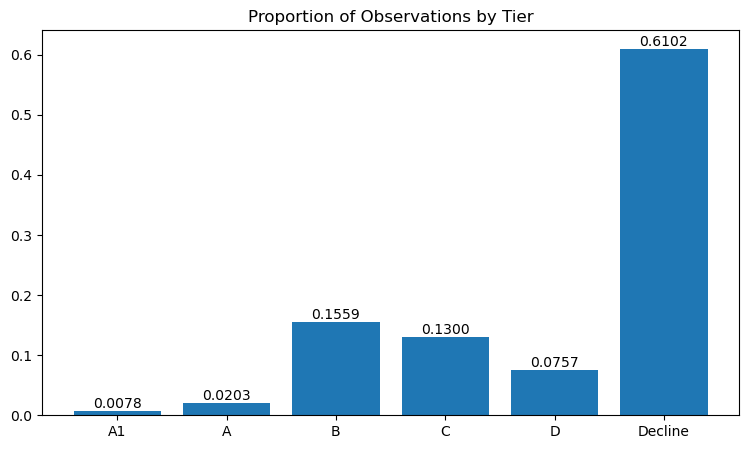

In [18]:
ser_freq = df['Tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier', 'Prop']
df_freq['sort'] = df_freq['Tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# graph
x = df_freq['Tier']
y = df_freq['Prop']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Proportion of Observations by Tier')
bars = ax.bar(x, y)
ax.bar_label(bars, fmt='%.4f')
# show
plt.show()

#### Save locally

In [19]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 489 ms, sys: 20 ms, total: 509 ms
Wall time: 508 ms


#### Look at early pays

In [20]:
# early pays
list_int_id = [
    8108510,
    8028278,
    8038696,
    8066225,
    8059731,
    8096743,
    8073273,
    8311925,
    8107357,
    8094053,
    8010271,
    8015927,
    8016497,
    8111420,
    7997830,
    8038160,
    8114040,
    8303975,
]
df['accountid'] = df['accountid'].astype(int)
# subset
df_tmp = df[df['accountid'].isin(list_int_id)].copy()
# show
df_tmp

,accountid,request_datetime,response_model_name,Debtors,ENG-wtd_avg,ENG-bk,amtfinanced__app,bookvalue__app,ENG-loan_to_value,PD,LGD,ECNL,Tier
72126,7997830,2024-07-25 19:30:32+00:00,PRESTIGE-GEN-XII,1,[0.631578947368421],0,16933.88,14750.00,1.148060,0.767905,0.350185,0.634624,Decline
72394,8010271,2024-08-24 02:03:02+00:00,PRESTIGE-GEN-XII,1,[1.0],1,21049.90,16428.00,1.281343,0.237894,0.316725,0.177819,B
72521,8015927,2024-07-27 04:28:36+00:00,PRESTIGE-GEN-XII,2,"[0.0, 1.0]",0,14648.87,12600.00,1.162609,0.470402,0.350185,0.388757,Decline
72532,8016497,2024-08-12 23:57:03+00:00,PRESTIGE-GEN-XII,1,[1.0],0,17862.90,18775.00,0.951419,0.411927,0.277756,0.270021,C
72767,8028278,2024-08-02 22:58:15+00:00,PRESTIGE-GEN-XII,1,[1.0],0,23759.89,17741.00,1.339264,0.361689,0.390043,0.332935,D
73005,8038160,2024-08-09 21:56:32+00:00,PRESTIGE-GEN-XII,1,[0.05507246376811594],0,18786.69,16591.00,1.132342,0.501171,0.337281,0.398924,Decline
73018,8038696,2024-08-26 22:00:19+00:00,PRESTIGE-GEN-XII,1,[1.0],0,21689.37,14675.00,1.477981,0.349414,0.390415,0.321943,C
73394,8059731,2024-08-13 23:10:44+00:00,PRESTIGE-GEN-XII,1,[0.026124818577648767],0,16416.44,15302.00,1.072830,0.499847,0.337281,0.397870,Decline
73520,8066225,2024-09-11 04:28:50+00:00,PRESTIGE-GEN-XII,1,[0.0],0,19990.90,12625.00,1.583438,0.428229,0.416881,0.421309,Decline
73633,8073273,2024-08-28 04:53:12+00:00,PRESTIGE-GEN-XII,1,[0.0],0,38203.83,28389.18,1.345718,0.677982,0.390043,0.624083,Decline


#### Show tiers

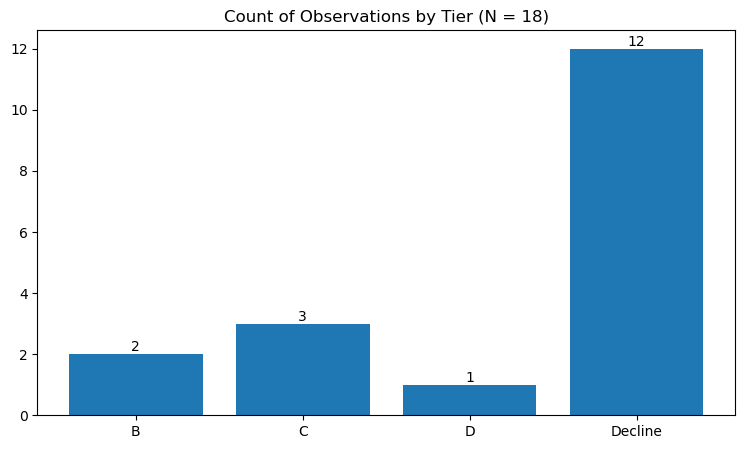

In [21]:
ser_freq = df_tmp['Tier'].value_counts(normalize=False)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier', 'Prop']
df_freq['sort'] = df_freq['Tier'].map(dict_sort)
df_freq.sort_values(by='sort', ascending=True, inplace=True)
df_freq.drop('sort', axis=1, inplace=True)

# graph
int_nrows = df_tmp.shape[0]
x = df_freq['Tier']
y = df_freq['Prop']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Count of Observations by Tier (N = {int_nrows})')
bars = ax.bar(x, y)
ax.bar_label(bars)

# save
str_filename = 'plt_early_pay_tier.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Save

In [22]:
str_filename = 'df_early_pay.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)